# Deliverable 2: Bayesian Inference - Search for Lost Object

This notebook contains the complete solution to the spatial search problem, including Bayesian updates after missions and generating the CSV output.

## 1. Initial Information & Setup

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import multivariate_normal
import datetime

# Constants
Nx, Ny = 50, 35
x_E = np.array([7, 20])
v_plane = np.array([6.0, -3.5])
v_wind = np.array([-1.0, -1.5])
v_drift = np.array([0.5, -1.5])
TOTAL_BUDGET = 230
team_id = "team_1"

# Load grid data
grid_df = pd.read_csv("grid_dataset.csv")

def plot_heatmap(df, column, title, show_vectors=False):
    pivot = df.pivot(index='y', columns='x', values=column)
    plt.figure(figsize=(10, 6))
    ax = sns.heatmap(pivot, cmap="viridis", robust=True, xticklabels=5, yticklabels=5)
    ax.set_xticklabels([int(float(t.get_text())) for t in ax.get_xticklabels()])
    ax.set_yticklabels([int(float(t.get_text())) for t in ax.get_yticklabels()])
    plt.title(title)
    if show_vectors:
        ax.scatter(x_E[0], x_E[1], color='red', marker='*', s=150, label='Accident (x_E)')
        ax.quiver(x_E[0], x_E[1], v_wind[0], v_wind[1], angles='xy', scale_units='xy', scale=1, color='cyan', label='Wind')
        ax.quiver(x_E[0], x_E[1], v_drift[0], v_drift[1], angles='xy', scale_units='xy', scale=1, color='orange', label='Drift')
        ax.quiver(x_E[0], x_E[1], v_plane[0], v_plane[1], angles='xy', scale_units='xy', scale=1, color='magenta', label='Plane')
        ax.legend()
    plt.gca().invert_yaxis()
    plt.show()

## Task 1: Prior Construction

We build a prior taking into account the accident location, momentum (plane velocity), wind, and drift.

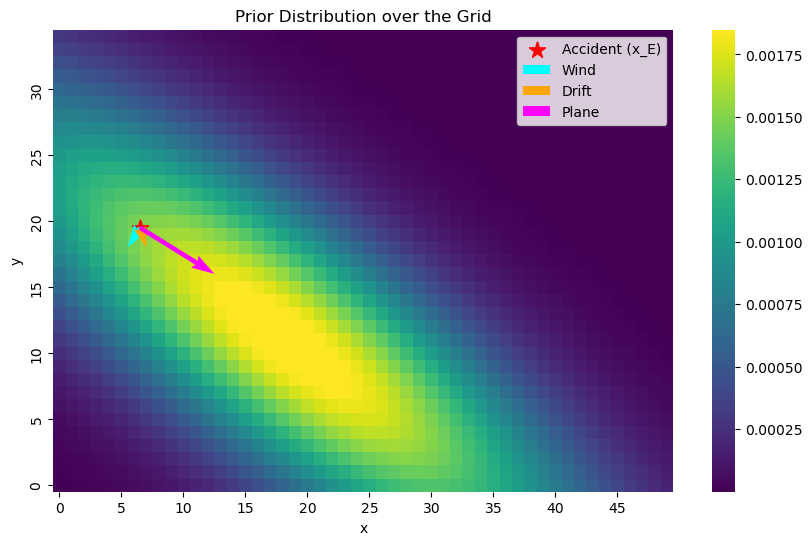

In [9]:
# Expected location based on physical vectors (reduced alpha to reflect vague witness priors)
alpha, beta = 2, 0.5
mu_prior = x_E + alpha * v_plane + beta * (v_wind + v_drift)

# Covariance aligned with the displacement vector
v_disp = alpha * v_plane + beta * (v_wind + v_drift)
theta = np.arctan2(v_disp[1], v_disp[0])
R = np.array([[np.cos(theta), -np.sin(theta)], 
              [np.sin(theta),  np.cos(theta)]])

# Define variances along the principal axes (increased to represent high uncertainty/vagueness)
sigma_long = 20.0
sigma_trans = 6.0
L = np.array([[sigma_long**2, 0], 
              [0, sigma_trans**2]])

cov_prior = R @ L @ R.T

# Prior over cells
pos = np.dstack((grid_df['x'], grid_df['y']))
rv = multivariate_normal(mu_prior, cov_prior)
grid_df['prior'] = rv.pdf(pos)
grid_df['prior'] /= grid_df['prior'].sum()

plot_heatmap(grid_df, 'prior', 'Prior Distribution over the Grid', show_vectors=True)

## Task 2: Detection Model

The detection model incorporates the effort $e_t$ and the environmental penalties from depth and roughness.

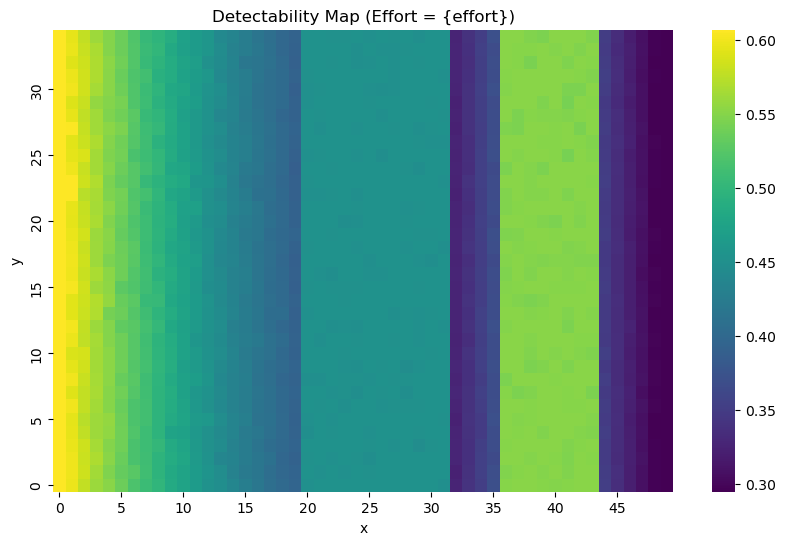

In [10]:
def detection_probability(effort, depth, roughness, lmbda=0.5, gamma_d=2.0, gamma_r=1.5):
    efficiency = 1 / (1 + gamma_d * depth + gamma_r * roughness)
    return 1 - np.exp(-lmbda * effort * efficiency)

grid_df['detectability_fixed_e1'] = detection_probability(3.0, grid_df['depth'], grid_df['roughness'])
plot_heatmap(grid_df, 'detectability_fixed_e1', r'Detectability Map (Effort = {effort})')

## Task 3: Posterior Update & Mission Tracking

We define a class to handle search missions, track the budget, update the posterior, and log the results to a CSV file.

In [11]:
class SearchMissionTracker:
    def __init__(self, grid_df, budget):
        self.grid_df = grid_df.copy()
        self.grid_df['posterior'] = self.grid_df['prior']
        self.budget = budget
        self.missions = []
        
    def search(self, x_min, x_max, y_min, y_max, effort, s_t=0):
        # Identify cells in the searched region
        in_region = (self.grid_df['x'] >= x_min) & (self.grid_df['x'] <= x_max) & \
                    (self.grid_df['y'] >= y_min) & (self.grid_df['y'] <= y_max)
        n_cells = in_region.sum()
        cost = effort * n_cells
        
        if cost > self.budget:
            print(f"Mission exceeds remaining budget ({self.budget}). Cost: {cost}")
            return
        
        # Calculate coverage and detection probability
        self.grid_df['c_t'] = in_region.astype(float)
        self.grid_df['rho_t'] = detection_probability(effort, self.grid_df['depth'], self.grid_df['roughness'])
        self.grid_df['q_t'] = self.grid_df['c_t'] * self.grid_df['rho_t']
        
        # Likelihood
        if s_t == 0:
            likelihood = 1 - self.grid_df['q_t']
        else:
            likelihood = self.grid_df['q_t']
            
        # Bayesian Update
        unnormalized_post = likelihood * self.grid_df['posterior']
        self.grid_df['posterior'] = unnormalized_post / unnormalized_post.sum()
        
        # Update budget and log
        self.budget -= cost
        mission_id = len(self.missions) + 1
        timestamp = datetime.datetime.now().isoformat()
        
        self.missions.append({
            'team_id': team_id,
            'mission_id': mission_id,
            'x_min': x_min, 'x_max': x_max,
            'y_min': y_min, 'y_max': y_max,
            'effort': effort,
            'n_cells': n_cells,
            'cost': cost,
            's_t': s_t,
            'budget_remaining': self.budget,
            'timestamp': timestamp
        })
        print(f"Mission {mission_id} completed. Cost: {cost:.2f}, Remaining Budget: {self.budget:.2f}")
        
    def plot_posterior(self):
        plot_heatmap(self.grid_df, 'posterior', 'Current Posterior Distribution')
        
    def export_missions(self, filename='missions.csv'):
        pd.DataFrame(self.missions).to_csv(filename, index=False)
        print(f"Exported {len(self.missions)} missions to {filename}")

tracker = SearchMissionTracker(grid_df, TOTAL_BUDGET)

### Conducting Search Missions
Based on qualitative reports from previous missions, let's conduct a few unsuccessful searches and observe the posterior update.

Mission 1 completed. Cost: 20.00, Remaining Budget: 210.00


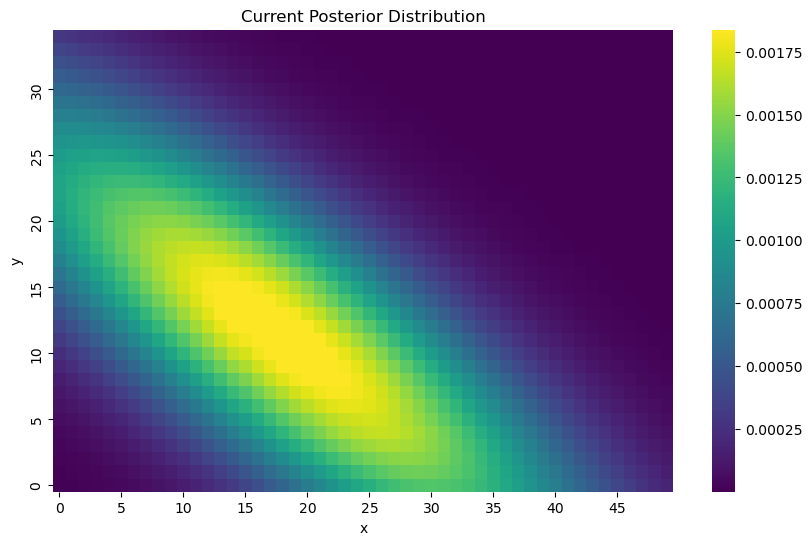

In [12]:
# Mission 1: Wide area, low effort
tracker.search(x_min=15, x_max=35, y_min=5, y_max=15, effort=0.1, s_t=0)
tracker.plot_posterior()

Mission 2 completed. Cost: 50.00, Remaining Budget: 160.00


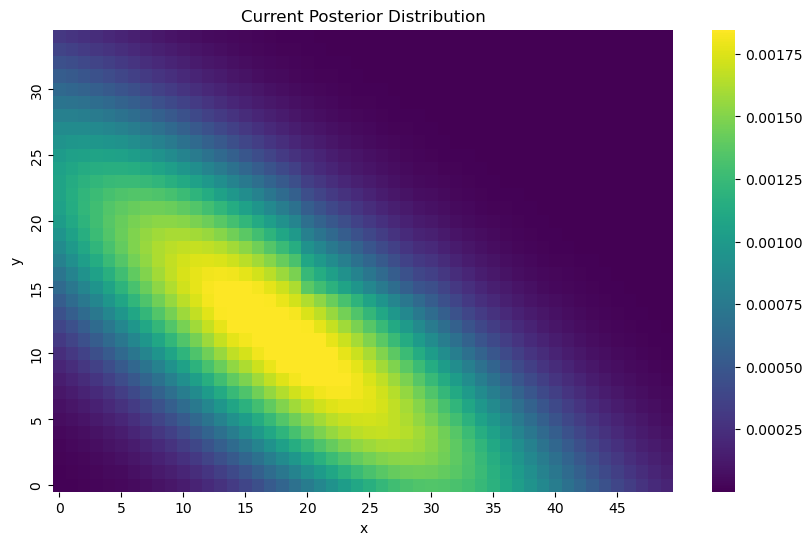

In [13]:
# Mission 2: Deep and irregular region, high effort
tracker.search(x_min=20, x_max=30, y_min=15, y_max=25, effort=0.5, s_t=0)
tracker.plot_posterior()

## Task 4: Next Search Mission

Given the updated posterior, we propose the next search region to maximize the probability of detection while respecting the remaining budget.

In [14]:
# Export the missions file
tracker.export_missions('missions.csv')

# Propose next mission (just viewing the current highest posterior regions)
top_cells = tracker.grid_df.sort_values(by='posterior', ascending=False).head(10)
display(top_cells[['x', 'y', 'posterior', 'depth', 'roughness']])

Exported 2 missions to missions.csv


,x,y,posterior,depth,roughness
568,18.5,11.5,0.001928,0.680672,0.358752
569,19.5,11.5,0.001924,0.718487,0.377148
519,19.5,10.5,0.001923,0.718487,0.390502
617,17.5,12.5,0.001922,0.642857,0.390192
618,18.5,12.5,0.001916,0.680672,0.387228
520,20.5,10.5,0.001913,0.741176,0.000000
567,17.5,11.5,0.001911,0.642857,0.369198
616,16.5,12.5,0.001907,0.605042,0.382729
518,18.5,10.5,0.001905,0.680672,0.382607
666,16.5,13.5,0.001904,0.605042,0.378317


## Task 5: Discussion

**Strengths**: The prior is physically motivated. The detection model realistically diminishes effort returns using exponential saturation, and depth/roughness are well-integrated as penalties.

**Limitations**: The combination of $\alpha$ and $\beta$ was somewhat arbitrary, lacking concrete variance estimation from the witnesses. The detection model hyperparameters ($\lambda, \gamma_d, \gamma_r$) were chosen heuristically.

**Improvements**: With more calibration data, we could formally fit the detection hyperparameters instead of picking them manually. We could also apply Monte Carlo sampling for physical uncertainty rather than assuming an analytical Gaussian.